In [1]:
%matplotlib widget

In [23]:
import math
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import List, Tuple, Union
from dataclasses import dataclass
from scipy.spatial import distance
from scipy.linalg import block_diag
from numpy import dot
from numpy.linalg import norm

In [24]:
import os
import sys

sys.path.append('/home/morita/src/3D_Estimation/src')

from plot import *
from calculate import *
from optimization import *

## 線源と検出器の座標系

### 線源
空間 10 * 10 * 10 [m] \
線源位置 [4.0,4.0,0.0], 100 Gy\
線源位置 [7.0,3.0,10.0], 200 Gy\
線源位置 [7.0,10,8.0], 150 Gy\

### 検出器
高さ 0.5 [m]

### 遮蔽
鉛 \
1/10に減衰

In [3]:
# 線源
source_1 = [3.5, 3.5, 0.0,100]
source_2 = [7.0,3.0,10.0,200]
source_3 = [7.0,10,8.0,150]
source_list = []
source_list.append(source_1)
source_list.append(source_2)
source_list.append(source_3)

In [4]:
# 部屋
x = 10
y = 10
z = 10

In [5]:
g = 1
q_max = 200
q_init = 1/q_max
q1 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q2 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 天井 z=10
q3 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面1 x=0
q4 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面2 y=0
q5 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面3 x=10
q6 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面4 y=10

In [6]:
def decide_measurement_points(x,y,r):
    m_p = []
    #z軸は固定
    m_p_c = []
    for i in range(x):
        for j in range(y):
            m_p_c.append([0.5+i,0.5+j,0.5])
    
    num_points = int(r * len(m_p_c))
    m_p = random.sample(m_p_c, num_points)
    return m_p

In [7]:
r = 0.7
m_p = decide_measurement_points(x,y,r)

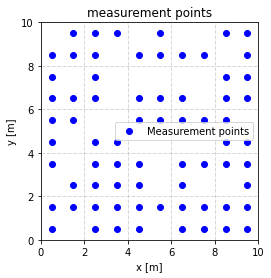

In [8]:
plot_measurement_points(m_p, source_list, "measurement points", x, y)

In [9]:
# 角度の8通りのシールド向きリスト
shield_orientations = [
    {'theta': (0, np.pi / 2), 'phi': (0, np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi / 2, np.pi)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (3 * np.pi / 2, 2 * np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (0, np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi / 2, np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (3 * np.pi / 2, 2 * np.pi)}
]


In [10]:
b_m = measurement_shield(m_p, source_list, shield_orientations)
print(len(b_m))
print(b_m)

560
[5.8087558784053765, 3.8489879867225913, 4.2700373339006905, 5.8087558784053765, 5.8087558784053765, 5.8087558784053765, 4.0896612365783716, 5.8087558784053765, 5.415462072438744, 6.701705915428638, 6.701705915428638, 5.525631348679559, 6.701705915428638, 6.701705915428638, 6.701705915428638, 3.144371458578698, 19.367032644167036, 22.18610804505922, 22.18610804505922, 22.18610804505922, 22.18610804505922, 5.077023276399984, 22.18610804505922, 22.18610804505922, 7.787629744936665, 9.90987717298231, 9.90987717298231, 9.90987717298231, 3.1308058495512916, 9.90987717298231, 9.90987717298231, 9.90987717298231, 7.348881779261526, 5.6379733023956025, 5.529687955758519, 7.348881779261526, 7.348881779261526, 7.348881779261526, 4.278020410527817, 7.348881779261526, 46.361286991758206, 47.62343258944618, 47.62343258944618, 46.03012536043579, 47.62343258944618, 47.62343258944618, 47.62343258944618, 7.702234795907964, 5.138413497523513, 2.5079839464673284, 5.138413497523513, 5.138413497523513, 

In [11]:
# 例: グリッド生成時に g の値を指定（省略可）
ground_grid = create_grid('z', 0, g=1)    # 地面 z=0
ceiling_grid = create_grid('z', 10, g=1)  # 天井 z=10
side1_grid = create_grid('x', 0, g=1)     # 側面1 x=0
side2_grid = create_grid('y', 0, g=1)     # 側面2 y=0
side3_grid = create_grid('x', 10, g=1)    # 側面3 x=10
side4_grid = create_grid('y', 10, g=1)    # 側面4 y=10


# 結果をリストとして保存
all_grids = {
    "ground": ground_grid,
    "ceiling": ceiling_grid,
    "side1": side1_grid,
    "side2": side2_grid,
    "side3": side3_grid,
    "side4": side4_grid
}

# 各面のグリッドを出力
for surface, grid in all_grids.items():
    print(f"{surface} grid:")
    print(grid)
    print()


ground grid:
[[0.5, 0.5, 0], [1.5, 0.5, 0], [2.5, 0.5, 0], [3.5, 0.5, 0], [4.5, 0.5, 0], [5.5, 0.5, 0], [6.5, 0.5, 0], [7.5, 0.5, 0], [8.5, 0.5, 0], [9.5, 0.5, 0], [0.5, 1.5, 0], [1.5, 1.5, 0], [2.5, 1.5, 0], [3.5, 1.5, 0], [4.5, 1.5, 0], [5.5, 1.5, 0], [6.5, 1.5, 0], [7.5, 1.5, 0], [8.5, 1.5, 0], [9.5, 1.5, 0], [0.5, 2.5, 0], [1.5, 2.5, 0], [2.5, 2.5, 0], [3.5, 2.5, 0], [4.5, 2.5, 0], [5.5, 2.5, 0], [6.5, 2.5, 0], [7.5, 2.5, 0], [8.5, 2.5, 0], [9.5, 2.5, 0], [0.5, 3.5, 0], [1.5, 3.5, 0], [2.5, 3.5, 0], [3.5, 3.5, 0], [4.5, 3.5, 0], [5.5, 3.5, 0], [6.5, 3.5, 0], [7.5, 3.5, 0], [8.5, 3.5, 0], [9.5, 3.5, 0], [0.5, 4.5, 0], [1.5, 4.5, 0], [2.5, 4.5, 0], [3.5, 4.5, 0], [4.5, 4.5, 0], [5.5, 4.5, 0], [6.5, 4.5, 0], [7.5, 4.5, 0], [8.5, 4.5, 0], [9.5, 4.5, 0], [0.5, 5.5, 0], [1.5, 5.5, 0], [2.5, 5.5, 0], [3.5, 5.5, 0], [4.5, 5.5, 0], [5.5, 5.5, 0], [6.5, 5.5, 0], [7.5, 5.5, 0], [8.5, 5.5, 0], [9.5, 5.5, 0], [0.5, 6.5, 0], [1.5, 6.5, 0], [2.5, 6.5, 0], [3.5, 6.5, 0], [4.5, 6.5, 0], [5.5, 6.5, 

In [12]:
# 各面のA行列の作成
A1 = create_A(10, 10, m_p, ground_grid, shield_orientations)  # 地面 z=0
A2 = create_A(10, 10, m_p, ceiling_grid, shield_orientations) # 天井 z=10
A3 = create_A(10, 10, m_p, side1_grid, shield_orientations)   # 側面1 x=0
A4= create_A(10, 10, m_p, side2_grid, shield_orientations)   # 側面2 y=0
A5= create_A(10, 10, m_p, side3_grid, shield_orientations)   # 側面3 x=10
A6 = create_A(10, 10, m_p, side4_grid, shield_orientations)   # 側面4 y=10

In [13]:
# 全体のA行列を結合
A = np.hstack((A1, A2, A3, A4, A5, A6))

print("Final A matrix:")
print(f"A: {A.shape}")

Final A matrix:
A: (560, 600)


In [14]:
q = np.vstack((q1, q2, q3, q4, q5, q6))
print(f"q: {q.shape}")
b = np.dot(A,q)
print(len(b))

q: (600, 1)
560


In [15]:
b_m_s = np.array(b_m)

In [16]:
init_score = score_func(A,b_m_s,q)
print(f'initial score{init_score}')

initial score-12726421.747666372


In [17]:
q_optimized = Adam(A, b_m_s, q, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=100000)

In [18]:
q_shapes = [
    (x * y, 1),  # 地面 z=0 に対応
    (x * y, 1),  # 天井 z=10 に対応
    (y * z, 1),  # 側面1 x=0 に対応
    (x * z, 1),  # 側面2 y=0 に対応
    (y * z, 1),  # 側面3 x=10 に対応
    (x * z, 1)   # 側面4 y=10 に対応
]
restored_qs = restore_q(q_optimized, q_shapes)

In [19]:
# 各qの最大値と最小値を求める
all_q_values = np.concatenate([q.flatten() for q in restored_qs])
vmin, vmax = all_q_values.min(), all_q_values.max()

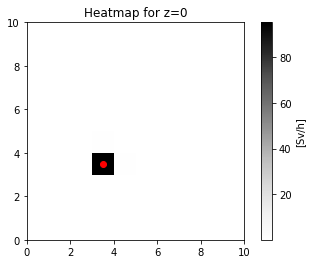

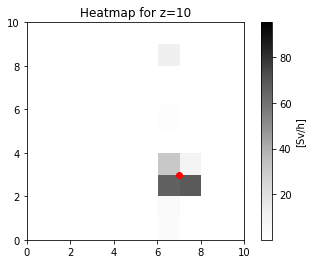

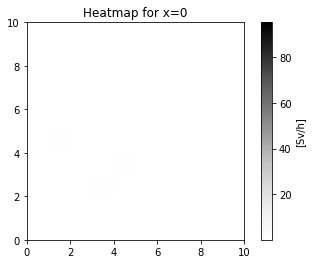

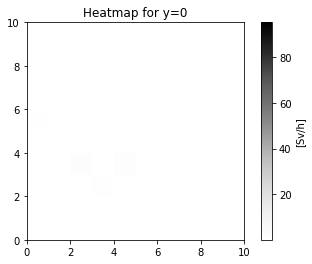

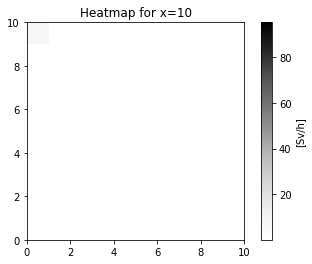

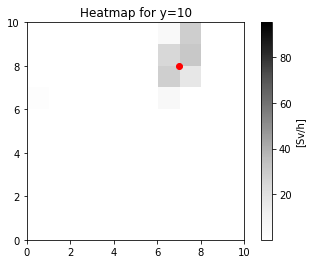

In [26]:
# 地面 z=0
plot_heatmap(restored_qs[0].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=0', sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin, vmax=vmax)

# 天井 z=10
plot_heatmap(restored_qs[1].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=10', sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin, vmax=vmax)

# 側面1 x=0
plot_heatmap(restored_qs[2].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=0', sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin, vmax=vmax)

# 側面2 y=0
plot_heatmap(restored_qs[3].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=0', sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin, vmax=vmax)

# 側面3 x=10
plot_heatmap(restored_qs[4].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=10', sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin, vmax=vmax)

# 側面4 y=10
plot_heatmap(restored_qs[5].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=10', sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin, vmax=vmax)

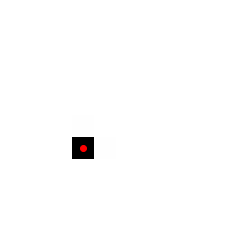

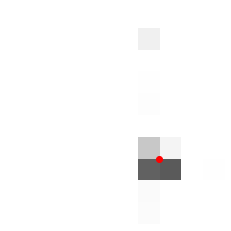

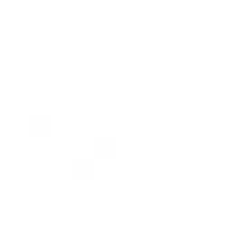

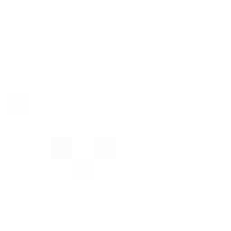

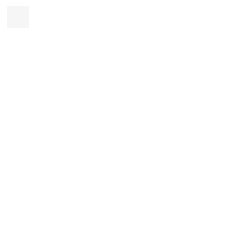

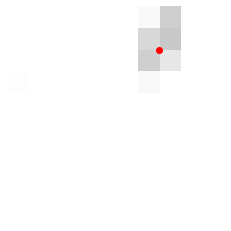

In [21]:
# 地面 z=0
plot_heatmap_result_no_colorbar(restored_qs[0].reshape((x, y)), (x, y), [0, x, 0, y], sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin, vmax=vmax)

# 天井 z=10
plot_heatmap_result_no_colorbar(restored_qs[1].reshape((x, y)), (x, y), [0, x, 0, y], sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin, vmax=vmax)

# 側面1 x=0
plot_heatmap_result_no_colorbar(restored_qs[2].reshape((y, z)), (y, z), [0, y, 0, z], sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin, vmax=vmax)

# 側面2 y=0
plot_heatmap_result_no_colorbar(restored_qs[3].reshape((x, z)), (x, z), [0, x, 0, z], sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin, vmax=vmax)

# 側面3 x=10
plot_heatmap_result_no_colorbar(restored_qs[4].reshape((y, z)), (y, z), [0, y, 0, z], sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin, vmax=vmax)

# 側面4 y=10
plot_heatmap_result_no_colorbar(restored_qs[5].reshape((x, z)), (x, z), [0, x, 0, z], sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin, vmax=vmax)


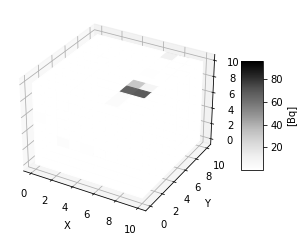

In [22]:
# 各面のデータと最小・最大の放射線量を設定
qs = restored_qs
vmin, vmax = all_q_values.min(), all_q_values.max()  # 先に計算された vmin, vmax

plot_3d_heatmap_cube(qs, x, y, z, sources=source_list, vmin=vmin, vmax=vmax)
